# Analisis y graficos

En esta libreta realizamos los analisis plateados en la [Libreta_planteamiento_de_insights](Libreta_planteamiento_de_insights.ipynb), usando los dos dataframes `df_player_latest` y `df_team_match` elaborados en la [Libreta_procesamiento_de_datos](Libreta_procesamiento_de_datos.ipynb).

## Lectura de datos y formateo basico

El script final va a continuar de la parte de procesado, por lo cual no se tendra que hacer lo que hacemos a continuacion. Esto solo es para segmentar los avances en distintas libretas de jupyter.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import math
import matplotlib.dates as mdates
import matplotlib.ticker as mtick

In [19]:
df_team_match = pd.read_csv("../OUTPUTS/df_team_match.csv")
df_player_latest_imputed = pd.read_csv("../OUTPUTS/df_player_latest_imputed.csv")
df_player_latest = pd.read_csv("../OUTPUTS/df_player_latest.csv")

df_team_match["DATE"] = pd.to_datetime(df_team_match["DATE"], errors="coerce").dt.floor("s")

df_player_latest["DATE"] = pd.to_datetime(df_player_latest["DATE"], errors="coerce").dt.floor("s")
df_player_latest["BIRTHDAY"] = pd.to_datetime(df_player_latest["BIRTHDAY"], errors="coerce").dt.floor("s")

df_player_latest_imputed["DATE"] = pd.to_datetime(df_player_latest_imputed["DATE"], errors="coerce").dt.floor("s")
df_player_latest_imputed["BIRTHDAY"] = pd.to_datetime(df_player_latest_imputed["BIRTHDAY"], errors="coerce").dt.floor("s")

# display(df_team_match.info())
# display(df_player_latest.info())
# display(df_player_latest_imputed.info())

In [20]:
COLOR_FONDO = "#F7F7F2"
COLOR_TEXTO = "#1F2937"
COLOR_GRID = "#D0D7DE"

COLOR_PRINCIPAL = "#1D4E89"
COLOR_SECUNDARIO = "#2A9D8F"
COLOR_RESALTE = "#E9C46A"
COLOR_ALERTA = "#D95D39"
COLOR_NEUTRO = "#8D99AE"

PALETA = [
    COLOR_PRINCIPAL,
    COLOR_SECUNDARIO,
    COLOR_RESALTE,
    COLOR_ALERTA,
    COLOR_NEUTRO,
    "#84A59D"
]

CMAP_CORR = "RdBu_r"

plt.rcParams.update({
    "figure.facecolor": COLOR_FONDO,
    "axes.facecolor": COLOR_FONDO,
    "savefig.facecolor": COLOR_FONDO,
    "axes.edgecolor": "#AAB4BE",
    "axes.labelcolor": COLOR_TEXTO,
    "axes.titlecolor": COLOR_TEXTO,
    "xtick.color": COLOR_TEXTO,
    "ytick.color": COLOR_TEXTO,
    "text.color": COLOR_TEXTO,
    "grid.color": COLOR_GRID,
    "grid.alpha": 0.35,
    "font.family": "sans-serif",
    "font.sans-serif": ["Aptos", "Segoe UI", "Calibri", "DejaVu Sans"],
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.dpi": 120
})

## Analisis 01: Que atributos de jugador de campo aportan informacion nueva y cuales son redundantes?

- Pregunta: Que atributos conviene mirar juntos y cuales son casi equivalentes al evaluar futbolistas de campo?
- Que se calcula?: Una matriz de correlacion entre variables numericas de Player_Attributes enfocado en jugadores de campo.
- Datos a usar: df_player_latest
- Grafico: Heatmap de correlaciones.
- Insight esperado: Simplificar criterios de scouting y evitar evaluar como si fueran independientes atributos que casi siempre se mueven juntos.

Como el usar datos nan complicaria el analisis, usaremos el `df_player_latest_imputed`.

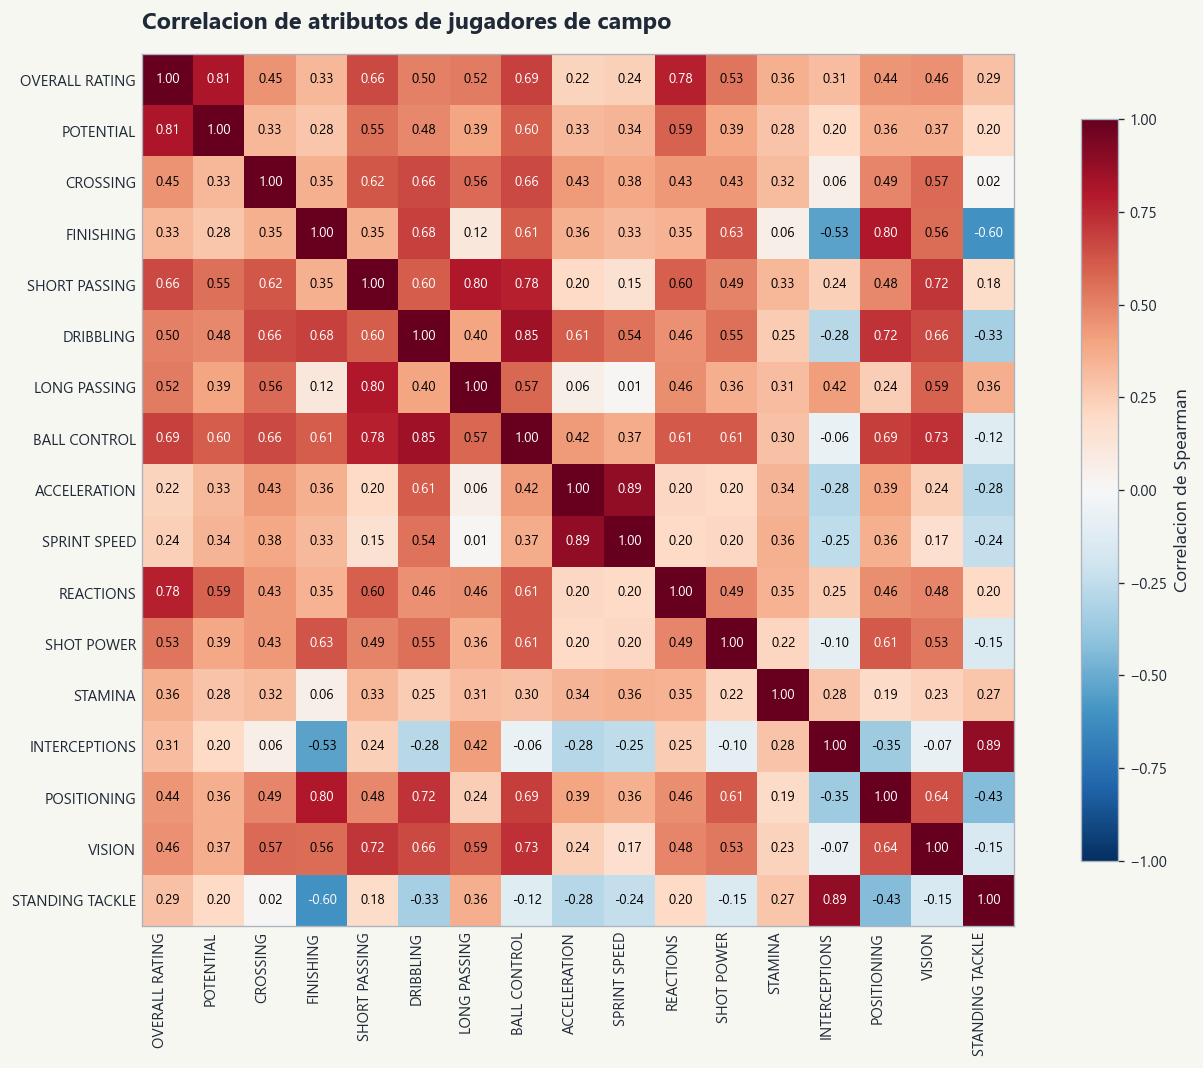

In [21]:
# Nos quedamos solo con jugadores de campo
df_outfield = df_player_latest_imputed.copy()
df_outfield = df_outfield[df_outfield["PLAYER_TYPE"] == "OUTFIELD"]

# Seleccionamos atributos relevantes para jugadores de campo
cols = [
    "OVERALL_RATING",
    "POTENTIAL",
    "CROSSING",
    "FINISHING",
    "SHORT_PASSING",
    "DRIBBLING",
    "LONG_PASSING",
    "BALL_CONTROL",
    "ACCELERATION",
    "SPRINT_SPEED",
    "REACTIONS",
    "SHOT_POWER",
    "STAMINA",
    "INTERCEPTIONS",
    "POSITIONING",
    "VISION",
    "STANDING_TACKLE"
]

# Calculamos la matriz de correlacion
df_corr = df_outfield[cols].copy()
corr = df_corr.corr(method = "spearman")

# Preparamos labels mas limpios para el grafico
labels = [col.replace("_", " ") for col in corr.columns]

# Graficamos el heatmap
fig, ax = plt.subplots(figsize = (12, 9))
im = ax.imshow(corr.values, cmap = CMAP_CORR, vmin = -1, vmax = 1)

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation = 90, ha = "right")
ax.set_yticklabels(labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        value = corr.values[i, j]
        color = "white" if abs(value) >= 0.60 else "black"
        text = ax.text(j, i, f"{value:.2f}", ha = "center", va = "center", color = color, fontsize = 8)

ax.set_title("Correlacion de atributos de jugadores de campo", loc = "left", pad = 15)
ax.tick_params(length = 0)
cbar = plt.colorbar(im, ax = ax, shrink=0.85)
cbar.set_label("Correlacion de Spearman")

fig.tight_layout()
plt.show()

### Analisis del grafico

En el heatmap de jugadores de campo se observan bloques claros de atributos que se mueven casi juntos. Por ejemplo, `ACCELERATION` y `SPRINT_SPEED` tienen una correlacion muy alta (`0.89`), lo que sugiere que ambas variables describen casi la misma dimension de rapidez. Algo parecido ocurre con `INTERCEPTIONS` y `STANDING_TACKLE` (`0.89`), que representan un perfil defensivo muy similar.

Tambien aparece un bloque tecnico-ofensivo bastante marcado. `DRIBBLING` y `BALL_CONTROL` tienen una correlacion alta (`0.85`), mientras que `SHORT_PASSING` y `LONG_PASSING` tambien se relacionan fuertemente (`0.80`). Ademas, `FINISHING` y `POSITIONING` muestran una correlacion importante (`0.80`), lo que indica que los jugadores que suelen ubicarse mejor en zonas de ataque tambien tienden a definir mejor.

A nivel general, `OVERALL_RATING` se relaciona bastante con `POTENTIAL` (`0.81`) y con `REACTIONS` (`0.78`). Esto sugiere que la valoracion global del jugador no depende de un solo atributo aislado, sino de combinaciones de tecnica, lectura de juego y capacidad fisica. En otras palabras, para scouting de jugadores de campo no conviene tratar todas estas variables como independientes, porque varias son parcialmente redundantes y pueden resumirse por bloques.

## Analisis 02: Que atributos de jugador portero aportan informacion nueva y cuales son redundantes?

- Pregunta: Que atributos conviene mirar juntos y cuales son casi equivalentes al evaluar futbolistas?
- Que se calcula?: Una matriz de correlacion entre variables numericas de Player_Attributes, idealmente usando correlacion de Spearman y separando jugadores de campo y porteros.
- Datos a usar: df_player_latest
- Grafico: Heatmap de correlaciones.
- Precauciones: Usar un solo snapshot por jugador; no incluir IDs, fechas ni variables de portero si se mezclan jugadores de campo; revisar valores faltantes y outliers.
- Como identificar si el resultado es relevante?: Si aparecen bloques claros de correlacion alta, por ejemplo velocidad, pase, defensa o fisico, y si eso permite reducir variables redundantes.
- Insight esperado: Simplificar criterios de scouting y evitar evaluar como si fueran independientes atributos que casi siempre se mueven juntos.

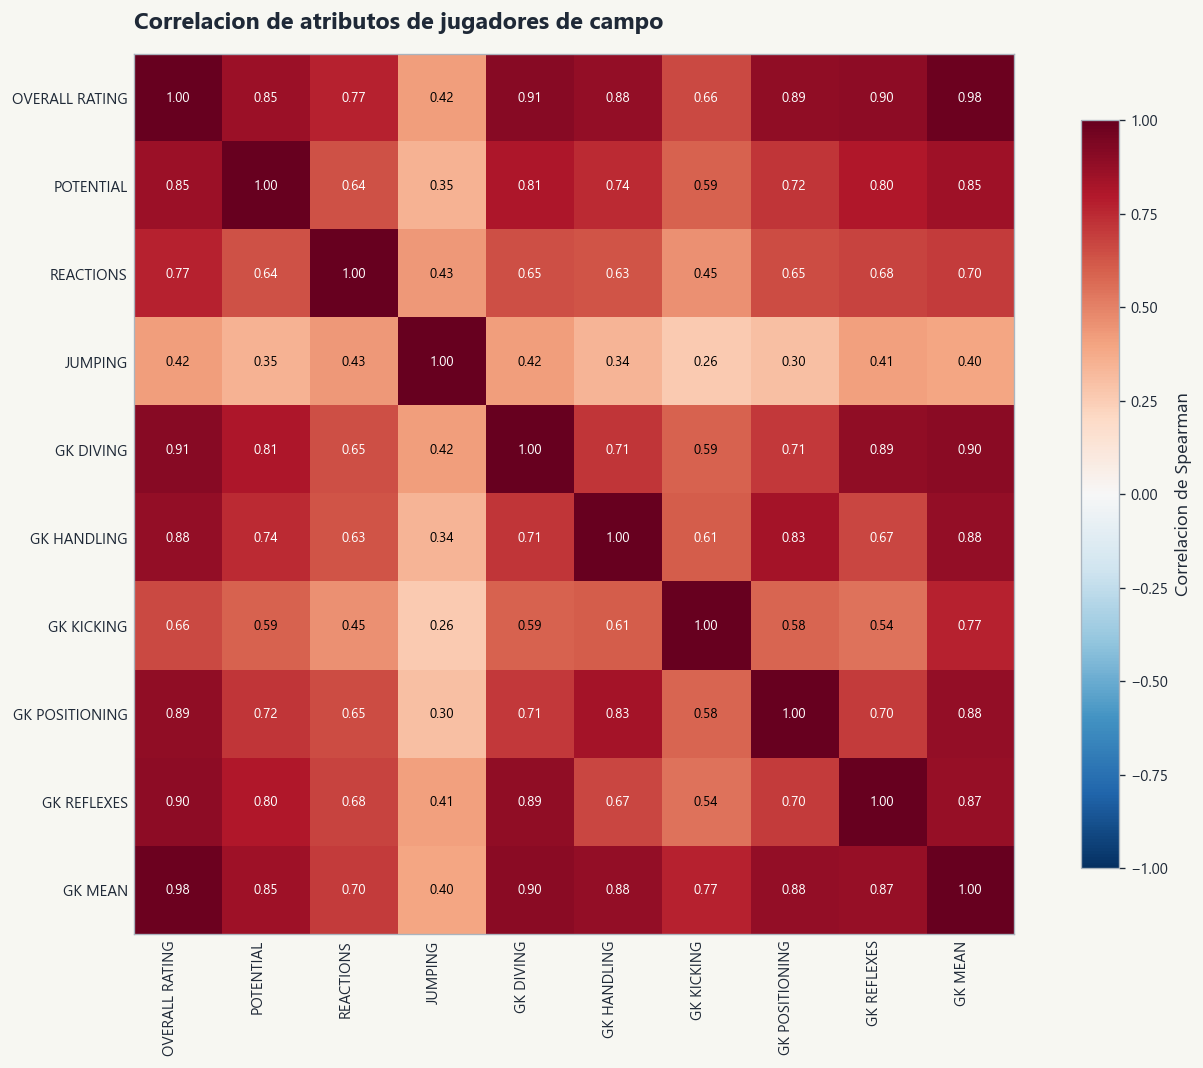

In [22]:
# Nos quedamos solo con porteros
df_goalkeepers = df_player_latest_imputed.copy()
df_goalkeepers = df_goalkeepers[df_goalkeepers["PLAYER_TYPE"] == "GOALKEEPER"]

# Seleccionamos atributos relevantes para porteros
cols = [
    "OVERALL_RATING",
    "POTENTIAL",
    "REACTIONS",
    "JUMPING",
    "GK_DIVING",
    "GK_HANDLING",
    "GK_KICKING",
    "GK_POSITIONING",
    "GK_REFLEXES",
    "GK_MEAN"
]

# Calculamos la matriz de correlacion
df_corr = df_goalkeepers[cols].copy()
corr = df_corr.corr(method = "spearman")

# Preparamos labels mas limpios para el grafico
labels = [col.replace("_", " ") for col in corr.columns]

# Graficamos el heatmap
fig, ax = plt.subplots(figsize = (12, 9))
im = ax.imshow(corr.values, cmap = CMAP_CORR, vmin = -1, vmax = 1)

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation = 90, ha = "right")
ax.set_yticklabels(labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        value = corr.values[i, j]
        color = "white" if abs(value) >= 0.60 else "black"
        text = ax.text(j, i, f"{value:.2f}", ha = "center", va = "center", color = color, fontsize = 8)

ax.set_title("Correlacion de atributos de jugadores de campo", loc = "left", pad = 15)
ax.tick_params(length = 0)

cbar = plt.colorbar(im, ax = ax, shrink = 0.85)
cbar.set_label("Correlacion de Spearman")

fig.tight_layout()
plt.show()

### Analisis del grafico

En el heatmap de porteros se observa una estructura mucho mas concentrada que en jugadores de campo. La variable `OVERALL_RATING` esta fuertemente relacionada con casi todos los atributos especificos de arquero, en especial con `GK_MEAN` (`0.98`), `GK_DIVING` (`0.91`), `GK_REFLEXES` (`0.90`), `GK_POSITIONING` (`0.89`) y `GK_HANDLING` (`0.88`). Esto indica que el rendimiento general del portero esta muy dominado por sus habilidades tecnicas propias del puesto.

Tambien se ven relaciones altas entre atributos internos del arco. Por ejemplo, `GK_DIVING` y `GK_REFLEXES` tienen una correlacion de `0.89`, mientras que `GK_POSITIONING` y `GK_HANDLING` alcanzan `0.83`. Esto sugiere que varios indicadores del portero miden casi la misma calidad subyacente, por lo que existe bastante redundancia entre ellos.

En cambio, `JUMPING` muestra una relacion bastante menor con el bloque principal de variables de arquero. Por ejemplo, su correlacion con `GK_MEAN` es solo de `0.40`. Esto sugiere que el salto aporta informacion complementaria, pero no explica tanto el nivel global del portero como las habilidades tecnicas de atajada, colocacion y reflejos.

En conjunto, este grafico sugiere que para evaluar porteros se puede resumir gran parte del perfil usando pocas variables clave, porque muchas de las metricas del puesto se mueven casi juntas. A diferencia de los jugadores de campo, aqui la redundancia es mas fuerte y el perfil parece estar mas concentrado en un solo bloque de rendimiento especializado.

## Analisis 03: Histograma del gap potencial - overall rating

PENDIENTE (falta ajustar el grafico de porteros)

- Tema: Distribucion del margen de desarrollo de los jugadores.
- Pregunta: Que tan comun es encontrar jugadores con una brecha grande entre su potencial y su rendimiento actual?
- Que se calcula?: La distribucion de la variable potential - overall_rating para medir cuanto margen de crecimiento tiene cada jugador.
- Datos a usar: df_player_latest
- Grafico: Histograma.
- Precauciones: Si quieren una lectura mas limpia, pueden enfocarse en jugadores jovenes; revisar que el dataset no mezcle varios snapshots por jugador; no sacar conclusiones fuertes si no revisan la edad.
- Como identificar si el resultado es relevante?: Si la distribucion muestra una cola derecha clara y permite distinguir entre jugadores con poco margen y jugadores que destacan por su potencial no desarrollado.
- Insight esperado: Definir mejor que tan raro o comun es encontrar prospectos reales y fijar umbrales practicos para shortlist de scouting.

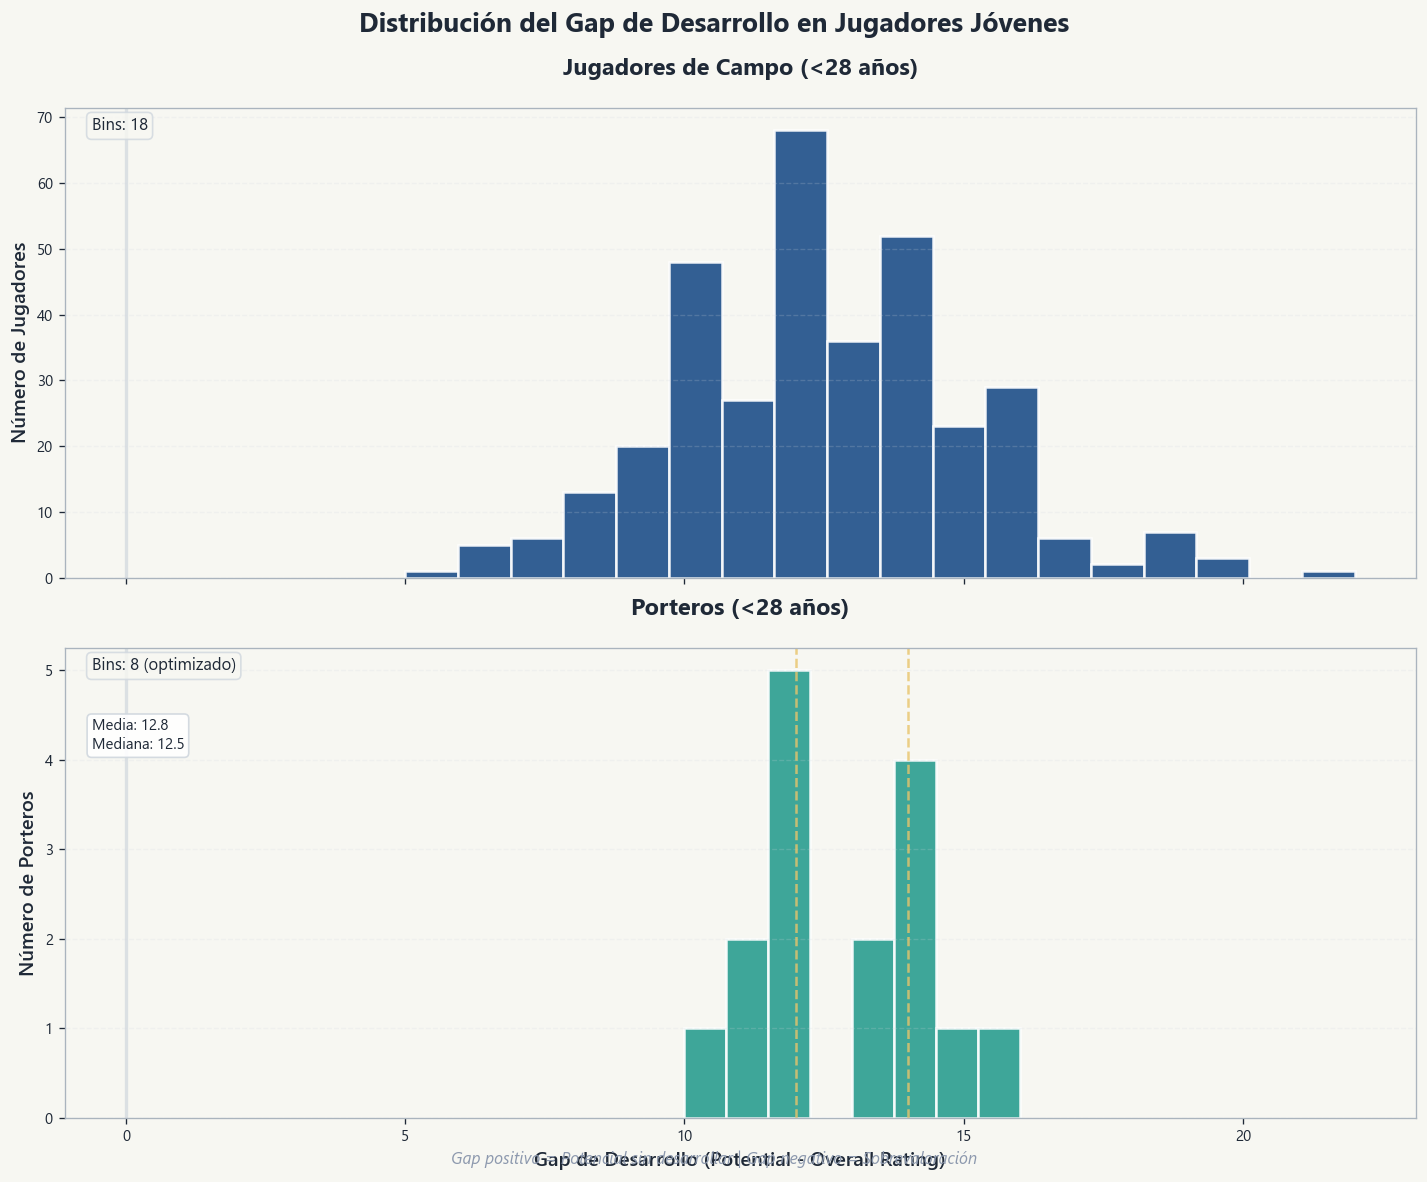

Jugadores de campo (<28 años):
  Muestra: 347 jugadores
  Gap promedio: 12.43
  Gap mediana: 12.00
  Gap maximo: 22
  Gap minimo: 5

Porteros (<28 años):
  Muestra: 16 porteros
  Gap promedio: 12.81
  Gap mediana: 12.50
  Gap maximo: 16
  Gap minimo: 10


In [23]:
# Calculamos la edad de los jugadores (asumiendo fecha actual aproximada)
fecha_actual = pd.Timestamp('2024-01-01')  # Fecha aproximada del dataset
df_gap = df_player_latest_imputed.copy()
df_gap["AGE"] = (fecha_actual - df_gap["BIRTHDAY"]).dt.days / 365.25

# Filtramos solo jugadores jovenes (menores a 28 años)
df_gap = df_gap[df_gap["AGE"] < 28].copy()

# Calculamos el gap entre potential y overall rating
df_gap["GAP"] = df_gap["POTENTIAL"] - df_gap["OVERALL_RATING"]

# Separamos porteros y jugadores de campo
df_gap_outfield = df_gap[df_gap["PLAYER_TYPE"] == "OUTFIELD"].copy()
df_gap_gk = df_gap[df_gap["PLAYER_TYPE"] == "GOALKEEPER"].copy()

# Calculamos bins usando raiz cuadrada del tamaño de muestra
bins_outfield = int(np.sqrt(len(df_gap_outfield)))

# Para porteros: estrategia mejorada para evitar histogramas vacíos
# Opción 1: Mínimo de bins garantizado (al menos 8-10 bins para visualización)
bins_gk_min = max(int(np.sqrt(len(df_gap_gk))), 8)

# Opción 2: Usar regla de Sturges como alternativa más conservadora
bins_gk_sturges = int(np.log2(len(df_gap_gk)) + 1) if len(df_gap_gk) > 0 else 5

# Opción 3: Basado en el rango de datos (IQR method)
if len(df_gap_gk) > 0:
    q75, q25 = np.percentile(df_gap_gk['GAP'].dropna(), [75, 25])
    iqr = q75 - q25
    bin_width = 2 * iqr / (len(df_gap_gk) ** (1/3))  # Regla de Freedman-Diaconis
    bins_gk_fd = int((df_gap_gk['GAP'].max() - df_gap_gk['GAP'].min()) / bin_width)
    bins_gk_fd = max(bins_gk_fd, 5)  # Mínimo 5 bins
else:
    bins_gk_fd = 5

# Elegimos la mejor opción: combinamos Sturges con mínimo garantizado
bins_gk = max(bins_gk_sturges, bins_gk_min, 8)

# Graficamos histogramas con estilos mejorados y presentables
fig, (ax1, ax2) = plt.subplots(2, 1, figsize = (12, 10), sharex = True)

# Estilo mejorado para histogramas
hist_style = {
    'alpha': 0.9,
    'edgecolor': 'white',
    'linewidth': 1.5,
    'histtype': 'bar'
}

# Histograma para jugadores de campo
n1, bins1, patches1 = ax1.hist(df_gap_outfield["GAP"].dropna(), bins = bins_outfield,
                               color = COLOR_PRINCIPAL, **hist_style)

# Añadimos línea de referencia en gap = 0
ax1.axvline(0, color = COLOR_GRID, linestyle = '-', linewidth = 2, alpha = 0.7, label = 'Gap = 0')

# Mejoramos el título y etiquetas
ax1.set_title("Jugadores de Campo (<28 años)", fontsize = 14, fontweight = "bold", pad = 20)
ax1.set_ylabel("Número de Jugadores", fontsize = 12, fontweight = "medium")
ax1.grid(axis = "y", alpha = 0.2, linestyle = "--", linewidth = 0.8)

# Añadimos información del número de bins
ax1.text(0.02, 0.98, f'Bins: {bins_outfield}', transform = ax1.transAxes,
         fontsize = 10, verticalalignment = 'top', bbox = dict(boxstyle = 'round,pad=0.3',
         facecolor = COLOR_FONDO, edgecolor = COLOR_GRID, alpha = 0.8))

# Histograma para porteros
n2, bins2, patches2 = ax2.hist(df_gap_gk["GAP"].dropna(), bins = bins_gk,
                               color = COLOR_SECUNDARIO, **hist_style)

# Añadimos línea de referencia en gap = 0
ax2.axvline(0, color = COLOR_GRID, linestyle = '-', linewidth = 2, alpha = 0.7, label = 'Gap = 0')

# Añadimos líneas de cuartiles para más contexto estadístico
if len(df_gap_gk) > 0:
    q25 = df_gap_gk['GAP'].quantile(0.25)
    q75 = df_gap_gk['GAP'].quantile(0.75)
    ax2.axvline(q25, color = COLOR_RESALTE, linestyle = '--', linewidth = 1.5, alpha = 0.8, label = f'Q1: {q25:.1f}')
    ax2.axvline(q75, color = COLOR_RESALTE, linestyle = '--', linewidth = 1.5, alpha = 0.8, label = f'Q3: {q75:.1f}')

# Mejoramos el título y etiquetas
ax2.set_title("Porteros (<28 años)", fontsize = 14, fontweight = "bold", pad = 20)
ax2.set_xlabel("Gap de Desarrollo (Potential - Overall Rating)", fontsize = 12, fontweight = "medium")
ax2.set_ylabel("Número de Porteros", fontsize = 12, fontweight = "medium")
ax2.grid(axis = "y", alpha = 0.2, linestyle = "--", linewidth = 0.8)

# Añadimos información del número de bins y método usado
ax2.text(0.02, 0.98, f'Bins: {bins_gk} (optimizado)', transform = ax2.transAxes,
         fontsize = 10, verticalalignment = 'top', bbox = dict(boxstyle = 'round,pad=0.3',
         facecolor = COLOR_FONDO, edgecolor = COLOR_GRID, alpha = 0.8))

# Añadimos estadísticas clave en el gráfico
if len(df_gap_gk) > 0:
    mean_gk = df_gap_gk['GAP'].mean()
    median_gk = df_gap_gk['GAP'].median()
    ax2.text(0.02, 0.85, f'Media: {mean_gk:.1f}\nMediana: {median_gk:.1f}',
             transform = ax2.transAxes, fontsize = 9, verticalalignment = 'top',
             bbox = dict(boxstyle = 'round,pad=0.3', facecolor = 'white', edgecolor = COLOR_GRID, alpha = 0.9))

# Título general de la figura
fig.suptitle("Distribución del Gap de Desarrollo en Jugadores Jóvenes",
             fontsize = 16, fontweight = "bold", y = 0.98)

# Ajustamos el layout
plt.tight_layout()
plt.subplots_adjust(top = 0.9, hspace = 0.15)

# Añadimos una nota explicativa
fig.text(0.5, 0.02,
         "Gap positivo = Potencial sin desarrollar | Gap negativo = Sobrevaloración",
         ha = 'center', fontsize = 10, style = 'italic', color = COLOR_NEUTRO)

plt.show()

# Estadisticas por grupo
print("Jugadores de campo (<28 años):")
print(f"  Muestra: {len(df_gap_outfield)} jugadores")
print(f"  Gap promedio: {df_gap_outfield['GAP'].mean():.2f}")
print(f"  Gap mediana: {df_gap_outfield['GAP'].median():.2f}")
print(f"  Gap maximo: {df_gap_outfield['GAP'].max():.0f}")
print(f"  Gap minimo: {df_gap_outfield['GAP'].min():.0f}")
print()
print("Porteros (<28 años):")
print(f"  Muestra: {len(df_gap_gk)} porteros")
print(f"  Gap promedio: {df_gap_gk['GAP'].mean():.2f}")
print(f"  Gap mediana: {df_gap_gk['GAP'].median():.2f}")
print(f"  Gap maximo: {df_gap_gk['GAP'].max():.0f}")
print(f"  Gap minimo: {df_gap_gk['GAP'].min():.0f}")

## Analisis 04: Grafico de barras de jugadores con alto potencial y overall todavia moderado

- Pregunta: Que atributos separan mejor a los jugadores jovenes con alto potencial del resto?
- Que se calcula?: La diferencia de promedios por atributo entre un grupo de jugadores jovenes de alto potencial y otro grupo de referencia de la misma edad.
- Datos a usar: df_player_latest
- Grafico: Grafico de barras horizontal.
- Insight esperado: Saber que rasgos vale mas la pena priorizar cuando se busca talento joven con margen de crecimiento.

Como el usar datos nan complicaria el analisis, usaremos el `df_player_latest_imputed`.

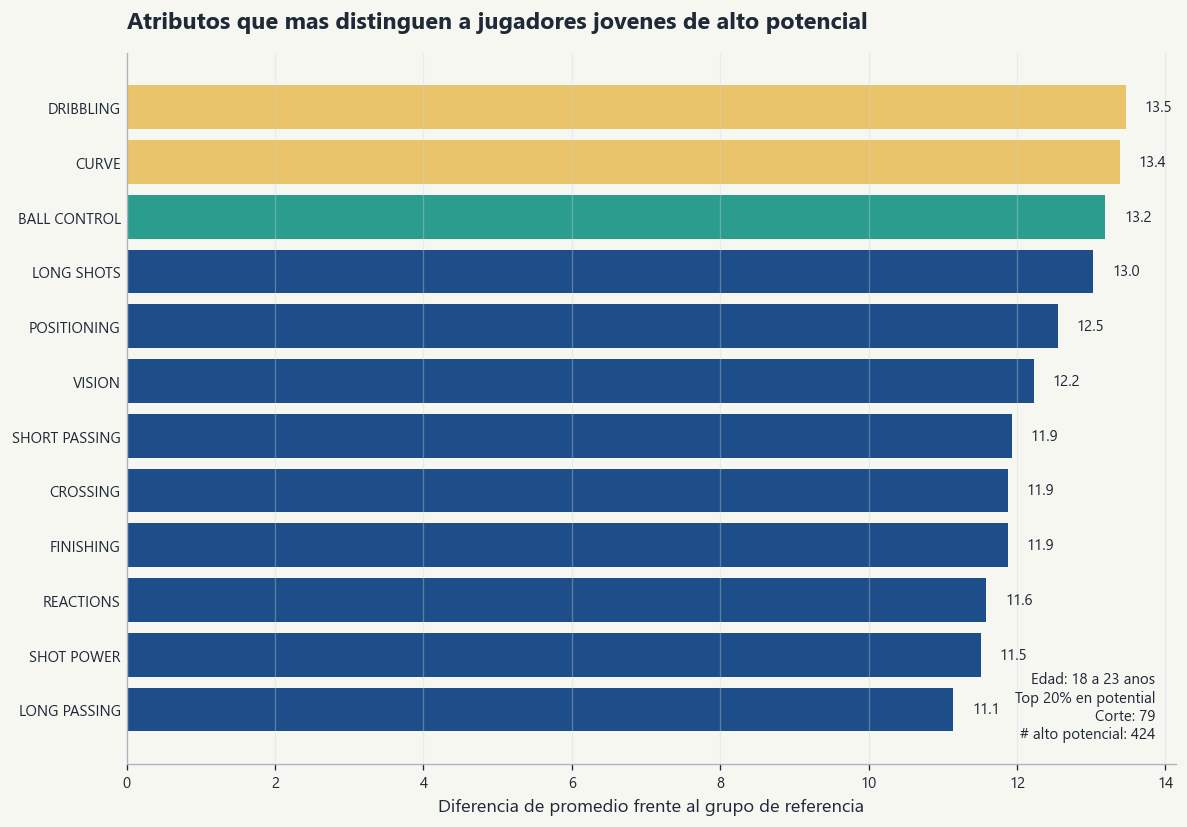

In [24]:
# Nos quedamos solo con jugadores de campo jovenes
df_young = df_player_latest_imputed.copy()
df_young = df_young[df_young["PLAYER_TYPE"] == "OUTFIELD"].copy()

# Calculamos edad aproximada al momento del snapshot
df_young["AGE"] = ((df_young["DATE"] - df_young["BIRTHDAY"]).dt.days / 365).round(1)

# Filtramos jugadores jovenes
df_young = df_young[df_young["AGE"].between(18, 23)].copy()

# Seleccionamos atributos de jugadores de campo
attr_cols = [
    "CROSSING",
    "FINISHING",
    "HEADING_ACCURACY",
    "SHORT_PASSING",
    "VOLLEYS",
    "DRIBBLING",
    "CURVE",
    "FREE_KICK_ACCURACY",
    "LONG_PASSING",
    "BALL_CONTROL",
    "ACCELERATION",
    "SPRINT_SPEED",
    "AGILITY",
    "REACTIONS",
    "BALANCE",
    "SHOT_POWER",
    "JUMPING",
    "STAMINA",
    "STRENGTH",
    "LONG_SHOTS",
    "AGGRESSION",
    "INTERCEPTIONS",
    "POSITIONING",
    "VISION",
    "PENALTIES",
    "MARKING",
    "STANDING_TACKLE",
    "SLIDING_TACKLE"
]

# Definimos el grupo de alto potencial como el top 20 por ciento
potential_cutoff = df_young["POTENTIAL"].quantile(0.80)

df_high_potential = df_young[df_young["POTENTIAL"] >= potential_cutoff].copy()
df_reference = df_young[df_young["POTENTIAL"] < potential_cutoff].copy()

# Calculamos diferencia de promedios por atributo
mean_diff = df_high_potential[attr_cols].mean() - df_reference[attr_cols].mean()

# Nos quedamos con los 12 atributos que mas distinguen al grupo
mean_diff = mean_diff.sort_values(ascending=False).head(12).sort_values()

# Preparamos labels y colores
labels = [col.replace("_", " ") for col in mean_diff.index]

bar_colors = [COLOR_PRINCIPAL] * len(mean_diff)
if len(bar_colors) >= 3:
    bar_colors[-1] = COLOR_RESALTE
    bar_colors[-2] = COLOR_RESALTE
    bar_colors[-3] = COLOR_SECUNDARIO

# Graficamos
fig, ax = plt.subplots(figsize = (10, 7))
bars = ax.barh(labels, mean_diff.values, color = bar_colors)

# Agregamos el valor al final de cada barra
for bar, value in zip(bars, mean_diff.values):
    ax.text(value + 0.25, bar.get_y() + bar.get_height() / 2, f"{value:.1f}", va = "center", fontsize = 9)

ax.axvline(0, color = COLOR_NEUTRO, linewidth = 1.2)

ax.set_title("Atributos que mas distinguen a jugadores jovenes de alto potencial", loc = "left", pad = 15)
ax.set_xlabel("Diferencia de promedio frente al grupo de referencia")
ax.set_ylabel("")
ax.grid(axis = "x")
ax.tick_params(axis = "y", length = 0)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.text(0.98, 0.03, f"Edad: 18 a 23 anos\nTop 20% en potential\nCorte: {potential_cutoff:.0f}\n# alto potencial: {len(df_high_potential)}", transform = ax.transAxes, ha = "right", va = "bottom", fontsize = 9)

fig.tight_layout()
plt.show()

### Analisis del grafico

En este grafico se observa que los jugadores jovenes de alto potencial no se diferencian tanto por atributos defensivos o fisicos puros, sino sobre todo por rasgos tecnicos y ofensivos. Los atributos que mas sobresalen son `DRIBBLING`, `CURVE`, `BALL_CONTROL`, `LONG_SHOTS`, `POSITIONING` y `VISION`, lo que sugiere que el techo de desarrollo suele estar mas asociado con calidad tecnica y capacidad ofensiva que con fuerza o juego defensivo.

Tambien destaca que `SHORT_PASSING`, `CROSSING`, `SHOT_POWER` y `REACTIONS` aparecen entre las diferencias mas altas. Esto sugiere que los jugadores mas prometedores no solo tienen habilidad individual, sino tambien mejores recursos para participar en la circulacion del balon y resolver jugadas con mas calidad.

En conjunto, el grafico sugiere que, al buscar talento joven con margen de crecimiento, conviene priorizar perfiles con buena tecnica ofensiva, control de balon y lectura de juego. De todos modos, este resultado debe interpretarse como una asociacion y no como causalidad, ya que tener estos atributos no garantiza por si solo que un jugador alcance su potencial.

## Analisis 05: Grafico de anillo del margen de victoria en los partidos

Pregunta: La mayoria de los partidos se decide por margenes pequenos?
Que se calcula?: La distribucion de la diferencia absoluta de goles, agrupada en categorias como 0, 1, 2 y 3+.
Datos a usar: Match, o idealmente df_match_base con goal_diff_abs ya calculado.
Grafico: Gráfico de anillo (donut chart) con porcentajes y etiqueta explicativa de diferencia absoluta de goles.
Insight esperado: Mostrar si los partidos suelen ser cerrados y si pequenos cambios pueden tener mucho impacto en el resultado.

Falta ajustar detalles

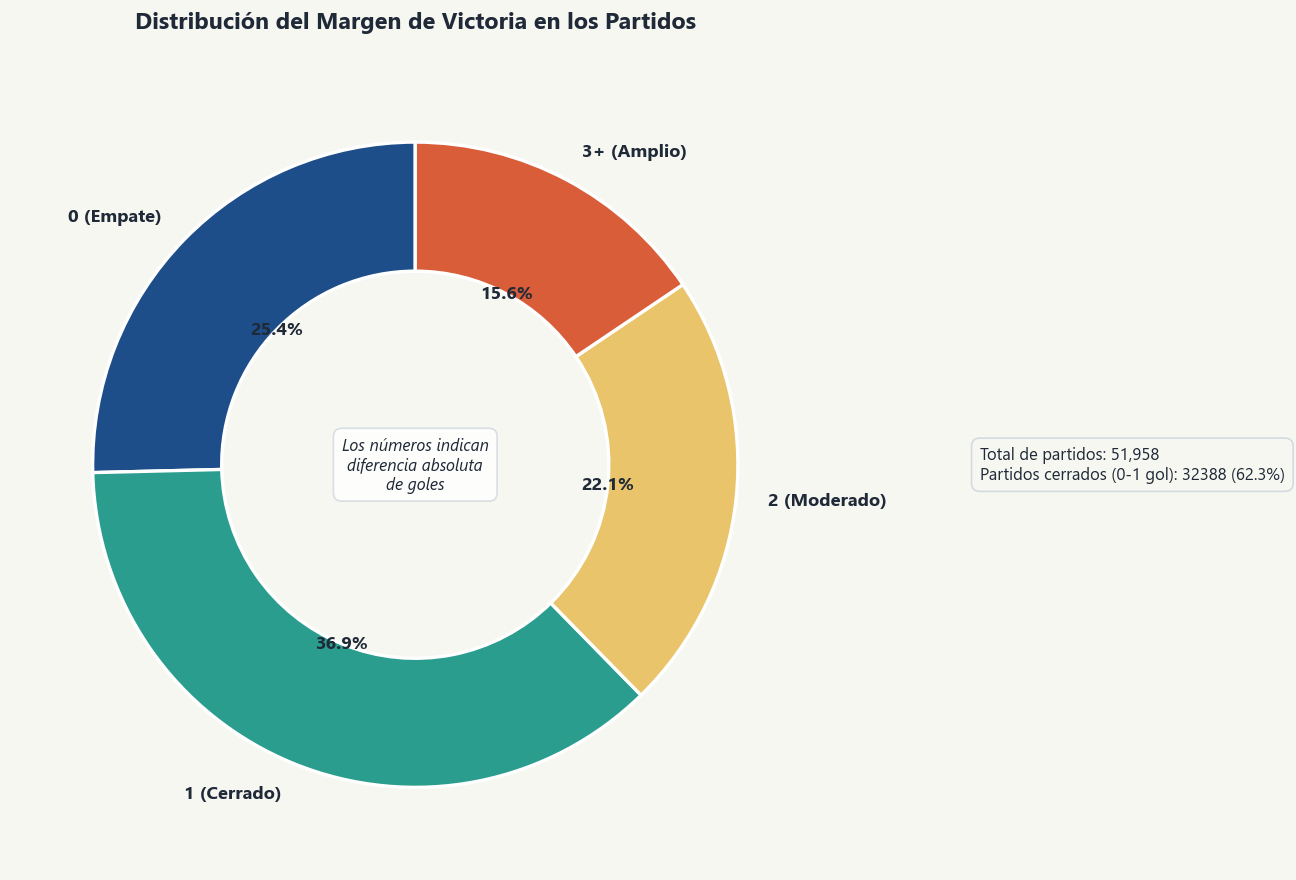

In [25]:
# Creamos categorias de margen absoluto de goles
df_margin = df_team_match.copy()

# Definimos categorias segun el margen
def categorizar_margen(abs_diff):
    if abs_diff == 0:
        return "0 (Empate)"
    elif abs_diff == 1:
        return "1 (Cerrado)"
    elif abs_diff == 2:
        return "2 (Moderado)"
    else:
        return "3+ (Amplio)"

df_margin["MARGEN_CATEGORIA"] = df_margin["ABS_GOAL_DIFF"].apply(categorizar_margen)

# Contamos frecuencias y calculamos porcentajes
margin_counts = df_margin["MARGEN_CATEGORIA"].value_counts()
margin_order = ["0 (Empate)", "1 (Cerrado)", "2 (Moderado)", "3+ (Amplio)"]
margin_counts = margin_counts.reindex(margin_order)
margin_pct = (margin_counts / margin_counts.sum()) * 100

# Graficamos como gráfico de anillo (donut chart)
fig, ax = plt.subplots(figsize = (10, 8))

# Crear el gráfico de anillo
wedges, texts, autotexts = ax.pie(margin_pct.values, 
                                  labels = margin_pct.index,
                                  autopct = '%1.1f%%',
                                  startangle = 90,
                                  colors = PALETA[:len(margin_pct)],
                                  wedgeprops = dict(width=0.4, edgecolor='white', linewidth=2),
                                  textprops = dict(fontsize=11, fontweight='bold'))

# Añadir título
ax.set_title("Distribución del Margen de Victoria en los Partidos", fontsize = 14, fontweight = "bold", pad = 20)

# Añadir etiqueta explicativa
ax.text(0, 0, "Los números indican\ndiferencia absoluta\nde goles", 
        ha='center', va='center', fontsize=10, style='italic', 
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor=COLOR_GRID, alpha=0.8))

# Añadir estadísticas en una caja de texto
stats_text = f"""Total de partidos: {margin_counts.sum():,}
Partidos cerrados (0-1 gol): {margin_counts[['0 (Empate)', '1 (Cerrado)']].sum()} ({(margin_counts[['0 (Empate)', '1 (Cerrado)']].sum() / margin_counts.sum() * 100):.1f}%)"""

ax.text(1.2, 0.5, stats_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='center', bbox=dict(boxstyle='round,pad=0.5', 
        facecolor=COLOR_FONDO, edgecolor=COLOR_GRID, alpha=0.9))

plt.tight_layout()
plt.show()